# 유럽 5대리그 선수 다음 시즌 득점 예측

## 1. 문제 정의

### 무엇을 예측하는가?

1. 다음 시즌 유럽 5대리그 득점 수 예측 (회귀)
2. 다음 시즌 10골 이상 득점 여부 예측 (분류)

### 어떤 선수를 대상으로 하는가?

현재 시즌 유럽 5대리그에서
FW 또는 MF 포지션으로 900분 이상 출전한 선수를 대상으로 한다.

### Target

회귀:
- `next_goals`
- 다음 시즌 유럽 5대리그에서 기록한 득점 수

분류:
- `next_10plus`
- 다음 시즌 10골 이상이면 1, 아니면 0

다음 시즌 유럽 5대리그 기록이 없는 선수는
`next_goals = 0`으로 처리한다.

### 사용할 데이터셋

먼저 `long_basic` 데이터셋으로 넓은 시즌 범위의 기본 피처를 사용하여 실험한다.

이후 시간이 된다면 `recent_advanced` 데이터셋을 사용하여
xG, xAG, 슈팅 등 고급 피처를 포함한 실험과 비교한다.

### Train / Validation / Test

이미 시즌 기준으로 분리된 데이터셋을 사용하며,
랜덤 분할은 하지 않는다.

- Train: 2000-01 → 2001-02 ~ 2022-23 → 2023-24
- Validation: 2023-24 → 2024-25
- Test: 2024-25 → 2025-26

### 평가 지표

회귀 모델:
- MAE
- RMSE
- R²

주요 평가 지표는 MAE를 사용한다.

In [ ]:
from pathlib import Path

filename = "09_01A_snapshot_conservative_labels.csv"

print("=== Google Drive ===")
for p in Path("/content/drive/MyDrive").rglob(filename):
    print(p)

print("\n=== Colab runtime ===")
for p in Path("/content").rglob(filename):
    print(p)

In [ ]:
# 2. 데이터 불러오기
import pandas as pd

# 파일 경로
train_path = "../data/long_basic/train.csv"
val_path = "../data/long_basic/validation.csv"
test_path = "../data/long_basic/test.csv"

# 데이터 불러오기
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Validation shape", val_df.shape)
print("Test shape", test_df.shape)




Train shape: (22430, 22)
Validation shape (923, 22)
Test shape (926, 22)


In [5]:
display(train_df.head())
display(val_df.head())
display(test_df.head())

,player,nation,team,league,season,target_season,position,position_group,age,matched_next,...,goals,assists,non_penalty_goals,penalty_goals,penalty_attempts,goals_per90,assists_per90,goal_contrib_per90,next_goals,next_10plus
0,Abdelhafid Tasfaout,dz ALG,Guingamp,Ligue 1,2000-2001,2001-2002,"FW,MF",FW,31.0,True,...,5.0,0.0,5.0,0.0,0.0,0.198413,0.000000,0.198413,1.0,0
1,Abder Ramdane,fr FRA,Freiburg,Bundesliga,2000-2001,2001-2002,"FW,MF",FW,26.0,True,...,3.0,1.0,3.0,0.0,0.0,0.181087,0.060362,0.241449,0.0,0
2,Adaílton,br BRA,Hellas Verona,Serie A,2000-2001,2001-2002,FW,FW,23.0,True,...,4.0,3.0,3.0,1.0,2.0,0.340265,0.255198,0.595463,1.0,0
3,Ade Akinbiyi,ng NGA,Leicester City,Premier League,2000-2001,2001-2002,FW,FW,25.0,True,...,9.0,2.0,9.0,0.0,0.0,0.287642,0.063920,0.351562,2.0,0
4,Adel Sellimi,tn TUN,Freiburg,Bundesliga,2000-2001,2001-2002,FW,FW,27.0,True,...,10.0,0.0,9.0,1.0,1.0,0.486224,0.000000,0.486224,5.0,0


,player,nation,team,league,season,target_season,position,position_group,age,matched_next,...,goals,assists,non_penalty_goals,penalty_goals,penalty_attempts,goals_per90,assists_per90,goal_contrib_per90,next_goals,next_10plus
0,Abde Ezzalzouli,MAR,Betis,La Liga,2023-2024,2024-2025,FW,FW,21.0,True,...,1,0,1,0,1,0.096463,0.000000,0.096463,2.0,0
1,Abdón Prats,ESP,Mallorca,La Liga,2023-2024,2024-2025,"FW,MF",FW,30.0,True,...,6,1,6,0,0,0.425197,0.070866,0.496063,2.0,0
2,Abdou Harroui,NED,Frosinone,Serie A,2023-2024,2024-2025,"MF,FW",FW,25.0,True,...,3,3,2,1,1,0.264966,0.264966,0.529931,1.0,0
3,Abdoulaye Doucouré,MLI,Everton,Premier League,2023-2024,2024-2025,"FW,MF",FW,30.0,True,...,7,1,7,0,0,0.239635,0.034234,0.273868,3.0,0
4,Abdoulaye Touré,GUI,Le Havre,Ligue 1,2023-2024,2024-2025,MF,MF,29.0,True,...,2,0,0,2,2,0.078809,0.000000,0.078809,10.0,1


,player,nation,team,league,season,target_season,position,position_group,age,matched_next,...,goals,assists,non_penalty_goals,penalty_goals,penalty_attempts,goals_per90,assists_per90,goal_contrib_per90,next_goals,next_10plus
0,Abdallah Sima,SEN,Brest,Ligue 1,2024-2025,2025-2026,"FW,MF",FW,23.0,True,...,7,2,7,0,0,0.508885,0.145396,0.654281,2.0,0
1,Abde Ezzalzouli,MAR,Betis,La Liga,2024-2025,2025-2026,"FW,MF",FW,22.0,True,...,2,2,2,0,1,0.090726,0.090726,0.181452,10.0,1
2,Abdoulaye Doucouré,MLI,Everton,Premier League,2024-2025,2025-2026,MF,MF,31.0,False,...,3,2,3,0,0,0.105304,0.070203,0.175507,0.0,0
3,Abdoulaye Touré,GUI,Le Havre,Ligue 1,2024-2025,2025-2026,MF,MF,30.0,True,...,10,1,2,8,9,0.387263,0.038726,0.425990,2.0,0
4,Abel Ruiz,ESP,Girona,La Liga,2024-2025,2025-2026,FW,FW,24.0,True,...,4,0,3,1,2,0.267459,0.000000,0.267459,0.0,0


In [ ]:
# 3. 데이터 구조 확인
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22430 entries, 0 to 22429
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   player              22430 non-null  str    
 1   nation              22424 non-null  str    
 2   team                22430 non-null  str    
 3   league              22430 non-null  str    
 4   season              22430 non-null  str    
 5   target_season       22430 non-null  str    
 6   position            22430 non-null  str    
 7   position_group      22430 non-null  str    
 8   age                 22430 non-null  float64
 9   matched_next        22430 non-null  bool   
 10  starts              22430 non-null  float64
 11  minutes             22430 non-null  float64
 12  goals               22430 non-null  float64
 13  assists             22430 non-null  float64
 14  non_penalty_goals   22430 non-null  float64
 15  penalty_goals       22430 non-null  float64
 16  penalty_attempt

In [9]:
train_df.dtypes

player                    str
nation                    str
team                      str
league                    str
season                    str
target_season             str
position                  str
position_group            str
age                   float64
matched_next             bool
starts                float64
minutes               float64
goals                 float64
assists               float64
non_penalty_goals     float64
penalty_goals         float64
penalty_attempts      float64
goals_per90           float64
assists_per90         float64
goal_contrib_per90    float64
next_goals            float64
next_10plus             int64
dtype: object

In [10]:
train_df.describe()

,age,starts,minutes,goals,assists,non_penalty_goals,penalty_goals,penalty_attempts,goals_per90,assists_per90,goal_contrib_per90,next_goals,next_10plus
count,22430.000000,22430.000000,22430.000000,22430.000000,22430.000000,22430.000000,22430.000000,22430.000000,22430.000000,22430.000000,22430.000000,22430.000000,22430.000000
mean,25.788096,22.055907,1950.667142,3.951048,2.511904,3.581275,0.366830,0.468301,0.178116,0.113698,0.291814,2.981275,0.083638
std,3.860258,7.661277,637.955222,4.587327,2.497279,4.077350,1.039754,1.222622,0.182977,0.103866,0.236253,4.509259,0.276850
min,16.000000,3.000000,900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,1407.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.041846,0.038265,0.104408,0.000000,0.000000
50%,26.000000,22.000000,1920.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.122734,0.091139,0.242828,1.000000,0.000000
75%,28.000000,28.000000,2463.000000,6.000000,4.000000,5.000000,0.000000,0.000000,0.266075,0.167832,0.425382,4.000000,0.000000
max,40.000000,57.000000,4994.000000,50.000000,21.000000,42.000000,14.000000,15.000000,1.562264,0.950226,1.935849,50.000000,1.000000


In [11]:
print("Train:", train_df["season"].unique())
print("Validation:", val_df["season"].unique())
print("Test:", test_df["season"].unique())

Train: <StringArray>
['2000-2001', '2001-2002', '2002-2003', '2003-2004', '2004-2005', '2005-2006',
 '2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012',
 '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018',
 '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023']
Length: 23, dtype: str
Validation: <StringArray>
['2023-2024']
Length: 1, dtype: str
Test: <StringArray>
['2024-2025']
Length: 1, dtype: str


In [12]:
train_df["next_goals"].describe()

count    22430.000000
mean         2.981275
std          4.509259
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         50.000000
Name: next_goals, dtype: float64

In [13]:
train_df["next_goals"].value_counts().sort_index()

next_goals
0.0     8830
1.0     3279
2.0     2259
3.0     1651
4.0     1292
5.0      952
6.0      800
7.0      599
8.0      493
9.0      399
10.0     316
11.0     298
12.0     237
13.0     179
14.0     139
15.0     122
16.0     120
17.0      73
18.0      61
19.0      46
20.0      42
21.0      31
22.0      35
23.0      27
24.0      34
25.0      17
26.0      17
27.0      13
28.0      16
29.0      12
30.0       9
31.0       7
32.0       2
33.0       1
34.0       4
35.0       3
36.0       5
37.0       1
38.0       1
40.0       2
41.0       1
43.0       1
46.0       2
48.0       1
50.0       1
Name: count, dtype: int64

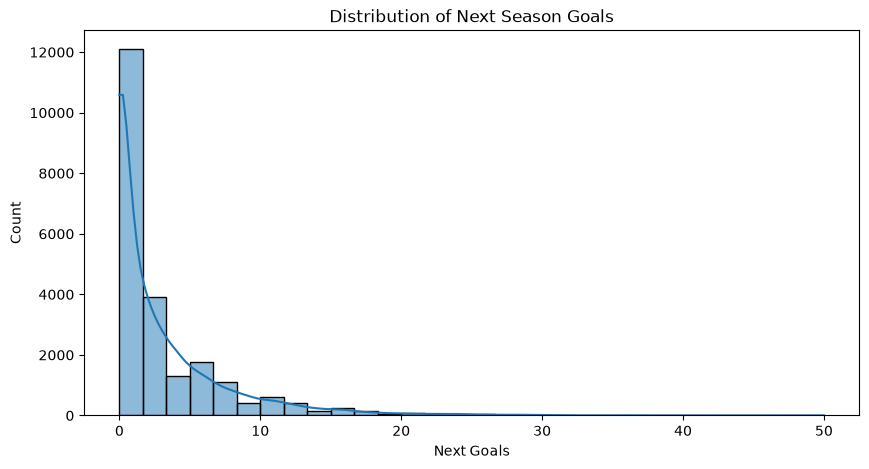

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(
    data=train_df,
    x="next_goals",
    bins=30,
    kde = True
)

plt.title("Distribution of Next Season Goals")
plt.xlabel("Next Goals")
plt.ylabel("Count")

plt.show()

In [16]:
train_df["next_10plus"].value_counts()

next_10plus
0    20554
1     1876
Name: count, dtype: int64

In [17]:
train_df["next_10plus"].value_counts(normalize=True)

next_10plus
0    0.916362
1    0.083638
Name: proportion, dtype: float64

In [18]:
print("개수")
print(train_df["next_10plus"].value_counts())

print("\n비율")
print(
    train_df["next_10plus"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

개수
next_10plus
0    20554
1     1876
Name: count, dtype: int64

비율
next_10plus
0    91.64
1     8.36
Name: proportion, dtype: float64


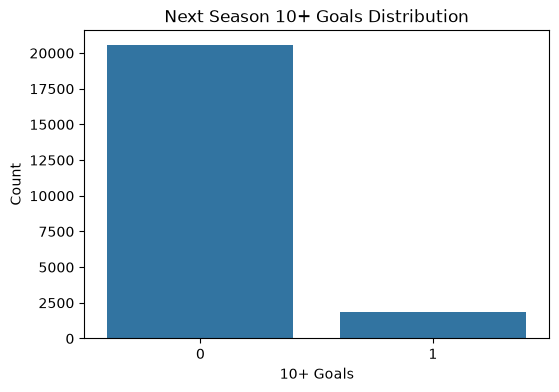

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=train_df,
    x="next_10plus"
)

plt.title("Next Season 10+ Goals Distribution")
plt.xlabel("10+ Goals")
plt.ylabel("Count")

plt.show()

### Target 분포 확인 결과

#### 회귀 Target: next_goals

- 다음 시즌 0골인 선수가 8,830명으로 가장 많다.
- 대부분의 선수가 낮은 득점 구간에 집중되어 있으며,
  고득점 선수가 소수 존재하는 오른쪽으로 치우친 분포를 보인다.
- 최대값은 50골이다.
- 향후 회귀 모델 평가 시 저득점 구간에 편향된 예측이 발생하는지 확인할 필요가 있다.

#### 분류 Target: next_10plus

- 10골 미만: 20,554명 (91.64%)
- 10골 이상: 1,876명 (8.36%)

10골 이상 선수 비율이 매우 낮아 클래스 불균형이 존재한다.
따라서 분류 실험에서는 Accuracy만 사용하지 않고
Precision, Recall, F1-score, ROC-AUC 등을 함께 확인한다.

In [23]:
# 4. 데이터 품질 확인
#   1. 결측치
#   2. 완전히 동일한 중복
#   3. matched_next 분포

train_df.isnull().sum()

player                0
nation                6
team                  0
league                0
season                0
target_season         0
position              0
position_group        0
age                   0
matched_next          0
starts                0
minutes               0
goals                 0
assists               0
non_penalty_goals     0
penalty_goals         0
penalty_attempts      0
goals_per90           0
assists_per90         0
goal_contrib_per90    0
next_goals            0
next_10plus           0
dtype: int64

In [ ]:
# 4-1. 결측치 확인

missing = train_df.isnull().sum()

missing[missing > 0]

nation    6
dtype: int64

In [ ]:
# 4-2. 완전히 동일한 중복 확인

train_df.duplicated().sum()

np.int64(0)

In [26]:
# 4-3. matched_next 확인

train_df["matched_next"].value_counts()

matched_next
True     18634
False     3796
Name: count, dtype: int64

In [28]:
# 비율 확인
train_df["matched_next"].value_counts(normalize=True) * 100

matched_next
True     83.076237
False    16.923763
Name: proportion, dtype: float64

In [30]:
print("개수")
print(train_df["matched_next"].value_counts())

print("\n비율")
print(
    train_df["matched_next"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

개수
matched_next
True     18634
False     3796
Name: count, dtype: int64

비율
matched_next
True     83.08
False    16.92
Name: proportion, dtype: float64


In [32]:
train_df.groupby("matched_next")["next_goals"].describe()

,count,mean,std,min,25%,50%,75%,max
matched_next,,,,,,,,
False,3796.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
True,18634.0,3.588601,4.721892,0.0,0.0,2.0,5.0,50.0


In [33]:
train_df.duplicated(
    subset=["player","team","season"]
).sum()

np.int64(0)

### 데이터 품질 확인 결과

- `nation` 컬럼에서 6개의 결측치가 확인되었다.
- 전체 데이터 대비 매우 적은 수이며, `nation`은 초기 모델 피처에서 제외할 예정이므로 현재 단계에서는 별도 처리하지 않는다.

- `matched_next=True`: 18,634명 (83.08%)
- `matched_next=False`: 3,796명 (16.92%)

- `matched_next=False`인 선수의 `next_goals`는 모두 0으로 확인되었다.
- 따라서 다음 시즌 유럽 5대리그 기록이 없는 선수를 `next_goals=0`으로 정의한 데이터 생성 규칙이 정상적으로 반영되어 있다.

- `player`, `team`, `season` 조합 기준 중복 데이터는 0개이다.

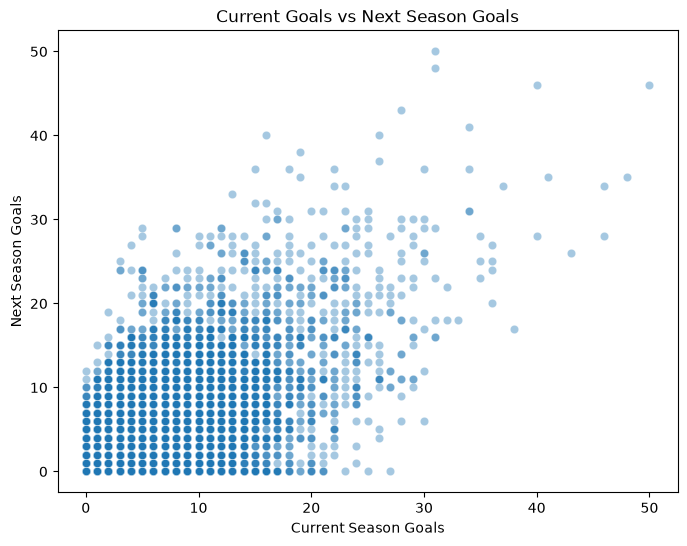

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=train_df,
    x="goals",
    y="next_goals",
    alpha=0.4
)

plt.title("Current Goals vs Next Season Goals")
plt.xlabel("Current Season Goals")
plt.ylabel("Next Season Goals")

plt.show()

In [36]:
train_df[["goals","next_goals"]].corr()

,goals,next_goals
goals,1.000000,0.651561
next_goals,0.651561,1.000000


In [37]:
# 5-2. 포지션별 다음 시즌 득점

train_df.groupby("position_group")["next_goals"].agg([
    "count",
    "mean",
    "median"
])


,count,mean,median
position_group,,,
FW,9736,4.994145,3.0
MF,12694,1.437451,1.0


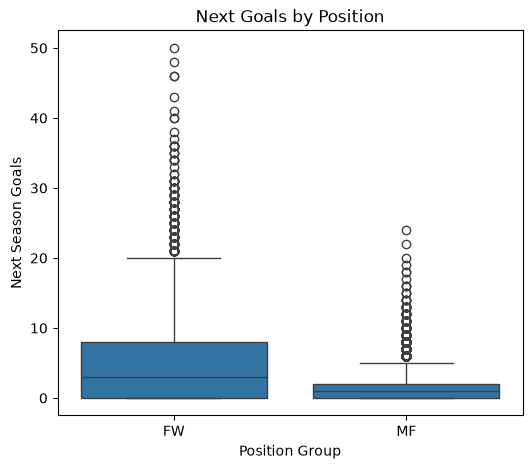

In [38]:
plt.figure(figsize=(6, 5))

sns.boxplot(
    data=train_df,
    x="position_group",
    y="next_goals"
)

plt.title("Next Goals by Position")
plt.xlabel("Position Group")
plt.ylabel("Next Season Goals")

plt.show()

In [39]:
league_summary = (
    train_df
    .groupby("league")["next_goals"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

league_summary

,count,mean,median
league,,,
Serie A,4385,3.177879,1.0
Premier League,4683,3.122998,1.0
La Liga,4629,3.041262,1.0
Bundesliga,4216,2.867647,1.0
Ligue 1,4517,2.688067,1.0


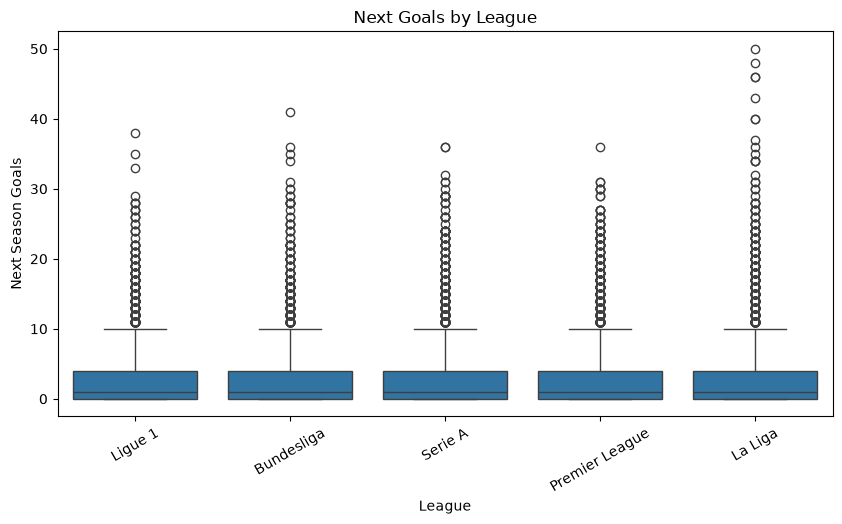

In [40]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=train_df,
    x="league",
    y="next_goals"
)

plt.xticks(rotation=30)

plt.title("Next Goals by League")
plt.xlabel("League")
plt.ylabel("Next Season Goals")

plt.show()

In [41]:
numeric_cols = train_df.select_dtypes(
    include=["int64", "float64"]
).columns

correlations = (
    train_df[numeric_cols]
    .corr()["next_goals"]
    .sort_values(ascending=False)
)

correlations

next_goals            1.000000
next_10plus           0.788251
goals                 0.651561
non_penalty_goals     0.637863
goals_per90           0.602566
goal_contrib_per90    0.589477
penalty_attempts      0.382121
penalty_goals         0.371800
assists               0.346331
assists_per90         0.279302
minutes               0.202647
starts                0.195589
age                  -0.082586
Name: next_goals, dtype: float64

In [42]:
correlations = (
    train_df[numeric_cols]
    .corr()["next_goals"]
    .drop("next_goals")
    .sort_values(ascending=False)
)

correlations

next_10plus           0.788251
goals                 0.651561
non_penalty_goals     0.637863
goals_per90           0.602566
goal_contrib_per90    0.589477
penalty_attempts      0.382121
penalty_goals         0.371800
assists               0.346331
assists_per90         0.279302
minutes               0.202647
starts                0.195589
age                  -0.082586
Name: next_goals, dtype: float64

In [46]:
correlations = (
    train_df[numeric_cols]
    .corr()["next_goals"]
    .drop("next_goals")
    .drop("next_10plus")
    .sort_values(ascending=False)
)

correlations

goals                 0.651561
non_penalty_goals     0.637863
goals_per90           0.602566
goal_contrib_per90    0.589477
penalty_attempts      0.382121
penalty_goals         0.371800
assists               0.346331
assists_per90         0.279302
minutes               0.202647
starts                0.195589
age                  -0.082586
Name: next_goals, dtype: float64

In [44]:
train_df.groupby("position_group")["next_goals"].agg([
    "count",
    "mean",
    "median"
])

,count,mean,median
position_group,,,
FW,9736,4.994145,3.0
MF,12694,1.437451,1.0


In [45]:
train_df.groupby("league")["next_goals"].agg([
    "count",
    "mean",
    "median"
])

,count,mean,median
league,,,
Bundesliga,4216,2.867647,1.0
La Liga,4629,3.041262,1.0
Ligue 1,4517,2.688067,1.0
Premier League,4683,3.122998,1.0
Serie A,4385,3.177879,1.0


### EDA 결과

#### 수치형 피처와 다음 시즌 득점

- 현재 시즌 `goals`와 다음 시즌 `next_goals`의 상관계수는 약 0.65로 가장 높은 수준을 보였다.
- `non_penalty_goals`, `goals_per90`, `goal_contrib_per90` 역시 비교적 높은 양의 상관관계를 보였다.
- 따라서 현재 시즌의 득점력 및 공격 기여도가 다음 시즌 득점 예측에 중요한 정보가 될 가능성이 있다.
- 반면 `minutes`, `starts`는 약한 양의 상관관계를 보였고 `age`는 매우 약한 음의 상관관계를 보였다.
- `next_10plus`는 `next_goals`에서 생성된 타깃 파생 변수이므로 모델 피처에서는 제외한다.

#### 포지션별 차이

- FW의 다음 시즌 평균 득점은 약 4.99골, MF는 약 1.44골이었다.
- 중앙값 역시 FW 3골, MF 1골로 차이가 확인되었다.
- 따라서 `position_group`은 다음 시즌 득점을 예측하는 데 중요한 범주형 피처가 될 가능성이 있다.

#### 리그별 차이

- 리그별 다음 시즌 평균 득점은 약 2.69~3.18골 범위였다.
- Serie A가 가장 높고 Ligue 1이 가장 낮았으나 차이는 약 0.5골 수준이었다.
- 모든 리그의 중앙값은 1골로 동일하여 포지션에 비해서는 리그별 차이가 크지 않았다.

In [47]:
# 회귀 Target
target_col = "next_goals"

# 초기 모델에서 사용할 범주형 피처
categorical_cols = [
    "league",
    "position_group"
]

# 초기 모델에서 사용할 수치형 피처
numeric_cols = [
    "age",
    "starts",
    "minutes",
    "goals",
    "assists",
    "non_penalty_goals",
    "penalty_goals",
    "penalty_attempts",
    "goals_per90",
    "assists_per90",
    "goal_contrib_per90"
]

# 초기 모델에서 제외
exclude_cols = [
    "player",
    "nation",
    "team",
    "season",
    "target_season",
    "position",
    "matched_next",
    "next_10plus"
]

In [48]:
feature_cols = categorical_cols + numeric_cols

print("사용 피처 수:", len(feature_cols))
print(feature_cols)

사용 피처 수: 13
['league', 'position_group', 'age', 'starts', 'minutes', 'goals', 'assists', 'non_penalty_goals', 'penalty_goals', 'penalty_attempts', 'goals_per90', 'assists_per90', 'goal_contrib_per90']


In [49]:
train_df[feature_cols].head()

,league,position_group,age,starts,minutes,goals,assists,non_penalty_goals,penalty_goals,penalty_attempts,goals_per90,assists_per90,goal_contrib_per90
0,Ligue 1,FW,31.0,26.0,2268.0,5.0,0.0,5.0,0.0,0.0,0.198413,0.000000,0.198413
1,Bundesliga,FW,26.0,15.0,1491.0,3.0,1.0,3.0,0.0,0.0,0.181087,0.060362,0.241449
2,Serie A,FW,23.0,10.0,1058.0,4.0,3.0,3.0,1.0,2.0,0.340265,0.255198,0.595463
3,Premier League,FW,25.0,33.0,2816.0,9.0,2.0,9.0,0.0,0.0,0.287642,0.063920,0.351562
4,Bundesliga,FW,27.0,21.0,1851.0,10.0,0.0,9.0,1.0,1.0,0.486224,0.000000,0.486224


In [50]:
# 사용할 피처
feature_cols = categorical_cols + numeric_cols

# Train
X_train = train_df[feature_cols]
y_train = train_df["next_goals"]

# Validation
X_val = val_df[feature_cols]
y_val = val_df["next_goals"]

# Test
X_test = test_df[feature_cols]
y_test = test_df["next_goals"]

In [52]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (22430, 13)
y_train: (22430,)
X_val: (923, 13)
y_val: (923,)
X_test: (926, 13)
y_test: (926,)


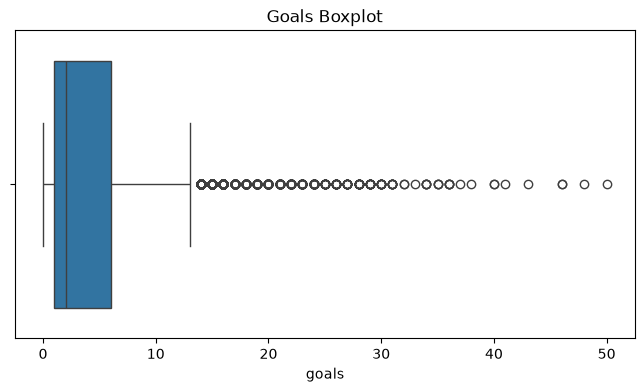

In [53]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=train_df,
    x="goals"
)

plt.title("Goals Boxplot")
plt.show()

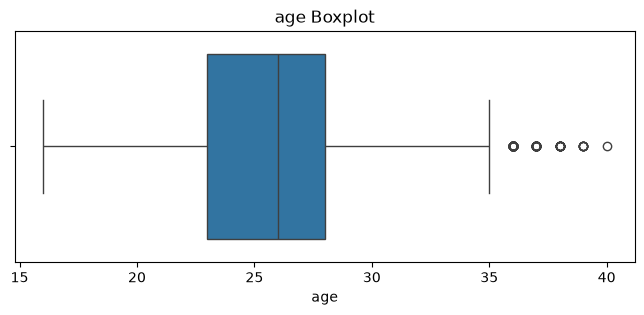

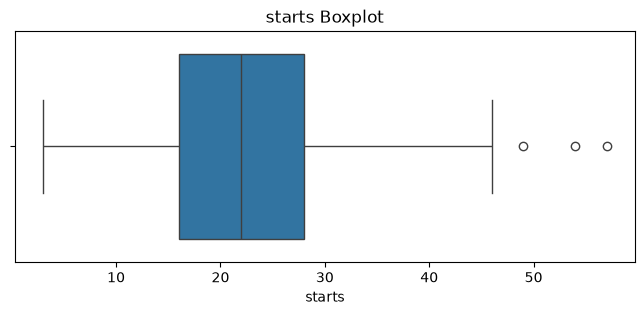

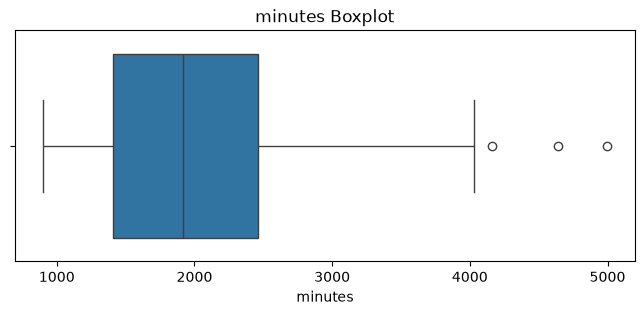

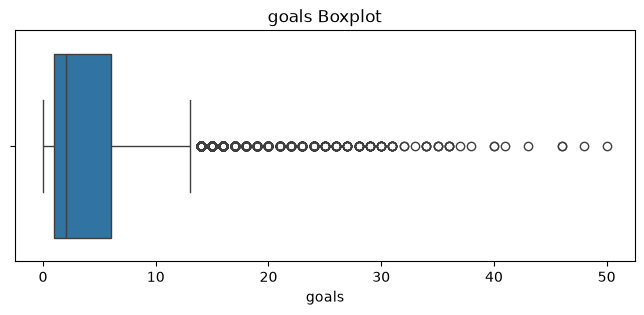

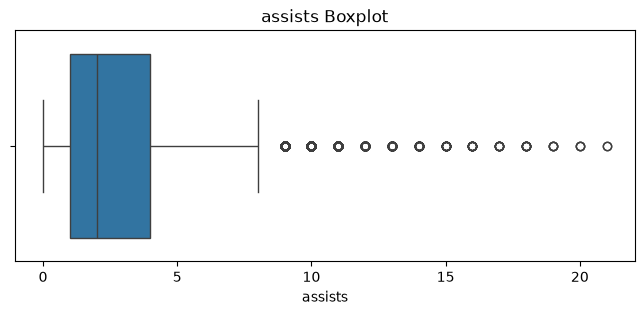

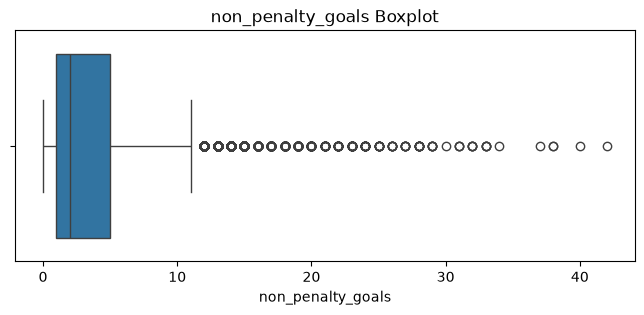

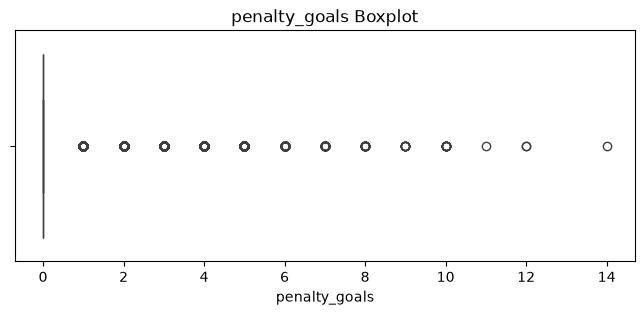

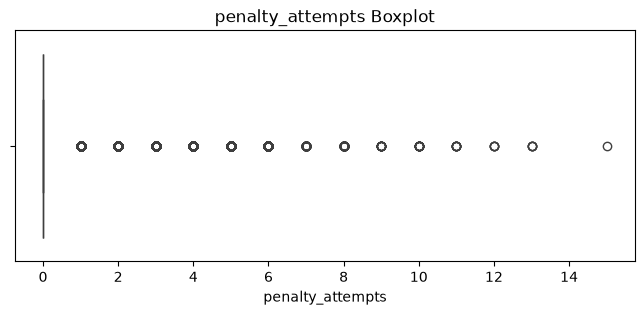

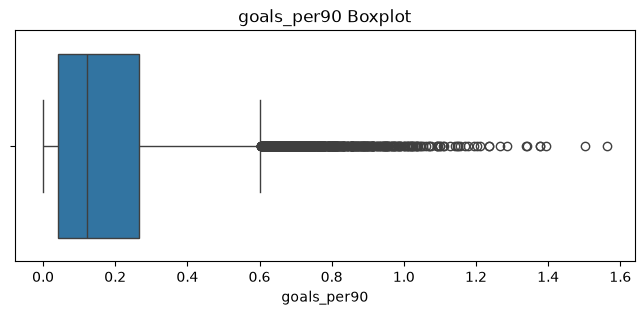

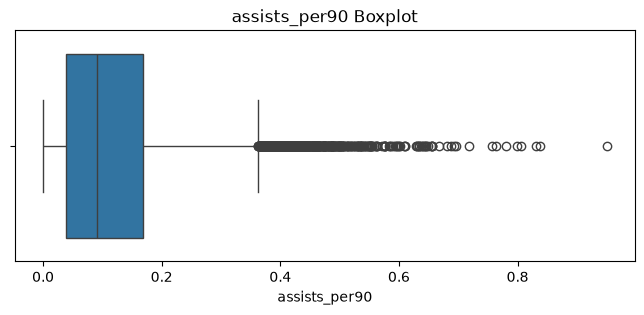

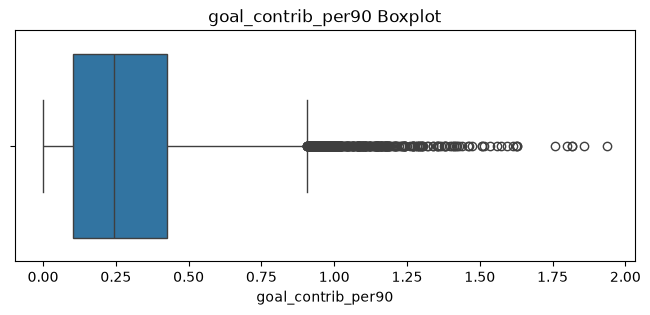

In [54]:
numeric_features = [
    "age",
    "starts",
    "minutes",
    "goals",
    "assists",
    "non_penalty_goals",
    "penalty_goals",
    "penalty_attempts",
    "goals_per90",
    "assists_per90",
    "goal_contrib_per90"
]

for col in numeric_features:
    plt.figure(figsize=(8, 3))
    sns.boxplot(data=train_df, x=col)
    plt.title(f"{col} Boxplot")
    plt.show()

In [56]:
train_df.nlargest(
    10,
    "minutes"
)[
    [
        "player",
        "team",
        "league",
        "season",
        "starts",
        "minutes",
        "goals"
    ]
]

,player,team,league,season,starts,minutes,goals
5422,Sergio,La Coruña,La Liga,2005-2006,57.0,4994.0,3.0
7398,Sergio,La Coruña,La Liga,2007-2008,54.0,4640.0,6.0
3507,Sergio,La Coruña,La Liga,2003-2004,49.0,4160.0,3.0
1657,Sergio,La Coruña,La Liga,2001-2002,45.0,4033.0,6.0
2570,Sergio,La Coruña,La Liga,2002-2003,46.0,3982.0,3.0
17113,Guilherme,La Coruña,La Liga,2017-2018,42.0,3583.0,2.0
8385,Sergio,La Coruña,La Liga,2008-2009,37.0,3425.0,5.0
1459,Matt Holland,Ipswich Town,Premier League,2001-2002,38.0,3420.0,3.0
2454,Olof Mellberg,Aston Villa,Premier League,2002-2003,38.0,3420.0,1.0
3140,Jlloyd Samuel,Aston Villa,Premier League,2003-2004,38.0,3420.0,2.0


In [57]:
train_df.nlargest(
    10,
    "starts"
)[
    [
        "player",
        "team",
        "league",
        "season",
        "starts",
        "minutes"
    ]
]

,player,team,league,season,starts,minutes
5422,Sergio,La Coruña,La Liga,2005-2006,57.0,4994.0
7398,Sergio,La Coruña,La Liga,2007-2008,54.0,4640.0
3507,Sergio,La Coruña,La Liga,2003-2004,49.0,4160.0
2570,Sergio,La Coruña,La Liga,2002-2003,46.0,3982.0
1657,Sergio,La Coruña,La Liga,2001-2002,45.0,4033.0
17113,Guilherme,La Coruña,La Liga,2017-2018,42.0,3583.0
475,Lee Bowyer,Leeds United,Premier League,2000-2001,38.0,3342.0
554,Martín Vellisca,Zaragoza,La Liga,2000-2001,38.0,3230.0
564,Matt Holland,Ipswich Town,Premier League,2000-2001,38.0,3379.0
668,Paul Merson,Aston Villa,Premier League,2000-2001,38.0,3364.0


### 이상치 처리 결정

- 득점, 도움, per90 등의 극단값은 실제 고성과 선수의 기록일 수 있으므로 단순 IQR 기준으로 제거하지 않는다.
- 특히 이번 프로젝트는 고득점 선수 예측이 중요하므로 통계적 이상치를 일괄 제거할 경우 중요한 정보를 손실할 수 있다.
- 다만 `starts`, `minutes`에서 일부 시즌 기록이 일반적인 리그 경기 수를 초과하는 값이 확인되었다.
- 해당 값은 단순 이상치로 제거하지 않고 원본 데이터 집계 문제 여부를 별도로 확인할 필요가 있다.
- 현재 베이스라인 실험에서는 값을 유지하고, 이후 필요 시 데이터 정제 실험을 추가한다.